In [1]:
# =============================================================================
# 12d — Statistics and figures
#
# Loads the tables written by 12c. Recomputes per-image discriminativeness
# so that E4 can carry confidence intervals.
#
# Pre-registered primary tests
#   E1  ha0 versus ha5, attention-CAM, MEL union, paired by image
#   E2  finercam versus gradcam_a, act ha5, MEL images only
# Everything else is exploratory and labelled as such.
# =============================================================================
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from PIL import Image
import cv2


def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError


REPO = find_repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.eval.cam_eval_utils import (
    cam_to_grid, norm01, mask_to_cam_grid, resize_centercrop_mask,
    CAM_GRID, RESIZE_SHORT, CROP_SIZE)

HAM_ROOT  = REPO / "data" / "HAM10000"
EVAL_ROOT = REPO / "outputs" / "mel_nv" / "eval_cams"
RES       = REPO / "results" / "overlap"
QC_CSV    = REPO / "results" / "annotation_qc" / "annotation_qc_manifest.csv"
FIG       = RES / "figures"
FIG.mkdir(parents=True, exist_ok=True)

long_df = pd.read_csv(RES / "overlap_metrics_long.csv")
cond_df = pd.read_csv(RES / "lesion_conditioned_metrics.csv")
nullcmp = pd.read_csv(RES / "observed_vs_null.csv")
pred    = pd.read_csv(EVAL_ROOT / "predictions.csv")
eval_df = pd.read_csv(EVAL_ROOT / "eval_images.csv")
man     = pd.read_csv(EVAL_ROOT / "cam_manifest.csv")
qcp     = pd.read_csv(QC_CSV).query("qc_pass")

TOP_K   = 20
N_BOOT  = 10000
ALPHAS  = ["ha0", "ha3", "ha5"]
AVAL    = {"ha0": 0, "ha3": 3, "ha5": 5}

C_ATTN = "#1F77B4"
C_ACT  = "#7F3F98"
C_NULL = "#BDBDBD"
C_MEL  = "#C62828"
C_NV   = "#2E7D32"

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300,
    "savefig.bbox": "tight", "font.size": 9,
    "axes.titlesize": 10, "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"long rows {len(long_df)}   cond rows {len(cond_df)}")
# print(f"images {eval_df.image_id.nunique()}   "
#       f"MEL union images {long_df.query('target == \"union_MEL\"').image_id.nunique()}")
# Calculate outside the f-string
mel_count = long_df.query('target == "union_MEL"').image_id.nunique()

print(f"long rows {len(long_df)}   cond rows {len(cond_df)}")
print(f"images {eval_df.image_id.nunique()}   "
      f"MEL union images {mel_count}")


long rows 3234   cond rows 990
long rows 3234   cond rows 990
images 34   MEL union images 31


In [2]:
# =============================================================================
# Wilcoxon signed rank with a bootstrap CI on the median paired difference.
#
# With n around 30 the CI is more informative than the p value. Report both.
# rank_biserial ranges -1 to 1. Positive means source A scores higher.
# =============================================================================
def paired_stats(df, metric, key_col, a, b, n_boot=N_BOOT, seed=0):
    p = (df.pivot_table(index="image_id", columns=key_col, values=metric)
           .loc[:, [a, b]].dropna())
    if len(p) < 5:
        return {"n": len(p), "note": "too few pairs"}

    d = (p[a] - p[b]).to_numpy()
    nz = d[d != 0]

    if len(nz) == 0:
        stat, pval, rb = np.nan, 1.0, 0.0
    else:
        stat, pval = wilcoxon(p[a], p[b])
        ranks = pd.Series(np.abs(nz)).rank().to_numpy()
        wp = ranks[nz > 0].sum()
        wm = ranks[nz < 0].sum()
        rb = (wp - wm) / (wp + wm)

    rng = np.random.default_rng(seed)
    boot = np.array([np.median(rng.choice(d, len(d), replace=True))
                     for _ in range(n_boot)])

    return {
        "n": len(p),
        f"median_{a}": float(np.median(p[a])),
        f"median_{b}": float(np.median(p[b])),
        "median_diff": float(np.median(d)),
        "ci_lo": float(np.percentile(boot, 2.5)),
        "ci_hi": float(np.percentile(boot, 97.5)),
        "p": float(pval),
        "rank_biserial": float(rb),
        "n_favour_a": int((d > 0).sum()),
        "n_favour_b": int((d < 0).sum()),
    }


def boot_median_ci(x, n_boot=N_BOOT, seed=0):
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    b = np.array([np.median(rng.choice(x, len(x), replace=True))
                  for _ in range(n_boot)])
    return float(np.median(x)), float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5))


def fmt(r):
    if "note" in r:
        return r["note"]
    return (f"n={r['n']}  diff={r['median_diff']:+.3f} "
            f"[{r['ci_lo']:+.3f}, {r['ci_hi']:+.3f}]  "
            f"p={r['p']:.4f}  r={r['rank_biserial']:+.2f}  "
            f"({r['n_favour_a']}/{r['n_favour_b']})")

In [3]:
# =============================================================================
# E1. Does alignment training improve overlap with clinician features.
# Target class CAM against the MEL feature union. Paired by image.
# =============================================================================
mel_raw = long_df.query("target == 'union_MEL'")
mel_con = cond_df.query("target == 'union_MEL'")

rows = []
for label, df, metric, ct_map in [
    ("attention, raw",        mel_raw, "cam_auc", "attncam_a"),
    ("attention, in-lesion",  mel_con, "c_auc",   "attncam_a"),
    ("activation, raw",       mel_raw, "cam_auc", "gradcam_a"),
    ("activation, in-lesion", mel_con, "c_auc",   "gradcam_a"),
]:
    sub = df[df.cam_type == ct_map]
    for a, b in [("ha3", "ha0"), ("ha5", "ha0"), ("ha5", "ha3")]:
        r = paired_stats(sub, metric, "ckpt", a, b)
        rows.append({"analysis": label, "contrast": f"{a} vs {b}", **r})

e1 = pd.DataFrame(rows)
e1.to_csv(RES / "E1_statistics.csv", index=False)

for lab in e1.analysis.unique():
    print(f"\n{lab}")
    for _, r in e1[e1.analysis == lab].iterrows():
        print(f"  {r.contrast:<12} {fmt(r)}")

print("\n\nPRIMARY TEST, attention raw, ha5 versus ha0")
pr = e1.query("analysis == 'attention, raw' and contrast == 'ha5 vs ha0'").iloc[0]
print(f"  median AUC  {pr['median_ha0']:.3f} -> {pr['median_ha5']:.3f}")
print(f"  difference  {pr.median_diff:+.3f}  95% CI [{pr.ci_lo:+.3f}, {pr.ci_hi:+.3f}]")
print(f"  p           {pr.p:.2e}")
print(f"  favours ha5 in {pr.n_favour_a} of {pr.n} images")


attention, raw
  ha3 vs ha0   n=31  diff=+0.357 [+0.284, +0.396]  p=0.0000  r=+1.00  (31/0)
  ha5 vs ha0   n=31  diff=+0.353 [+0.286, +0.391]  p=0.0000  r=+1.00  (31/0)
  ha5 vs ha3   n=31  diff=-0.000 [-0.005, +0.002]  p=0.3082  r=-0.21  (14/17)

attention, in-lesion
  ha3 vs ha0   n=31  diff=+0.172 [+0.100, +0.262]  p=0.0001  r=+0.76  (25/6)
  ha5 vs ha0   n=31  diff=+0.138 [+0.044, +0.249]  p=0.0008  r=+0.66  (24/7)
  ha5 vs ha3   n=31  diff=-0.013 [-0.033, +0.001]  p=0.0124  r=-0.51  (11/20)

activation, raw
  ha3 vs ha0   n=31  diff=+0.371 [+0.296, +0.491]  p=0.0000  r=+1.00  (31/0)
  ha5 vs ha0   n=31  diff=+0.374 [+0.298, +0.491]  p=0.0000  r=+1.00  (31/0)
  ha5 vs ha3   n=31  diff=+0.001 [+0.001, +0.003]  p=0.0002  r=+0.73  (25/6)

activation, in-lesion
  ha3 vs ha0   n=31  diff=+0.293 [+0.201, +0.401]  p=0.0000  r=+0.96  (28/3)
  ha5 vs ha0   n=31  diff=+0.294 [+0.214, +0.406]  p=0.0000  r=+0.96  (28/3)
  ha5 vs ha3   n=31  diff=+0.004 [+0.001, +0.006]  p=0.0759  r=+0.37  (21

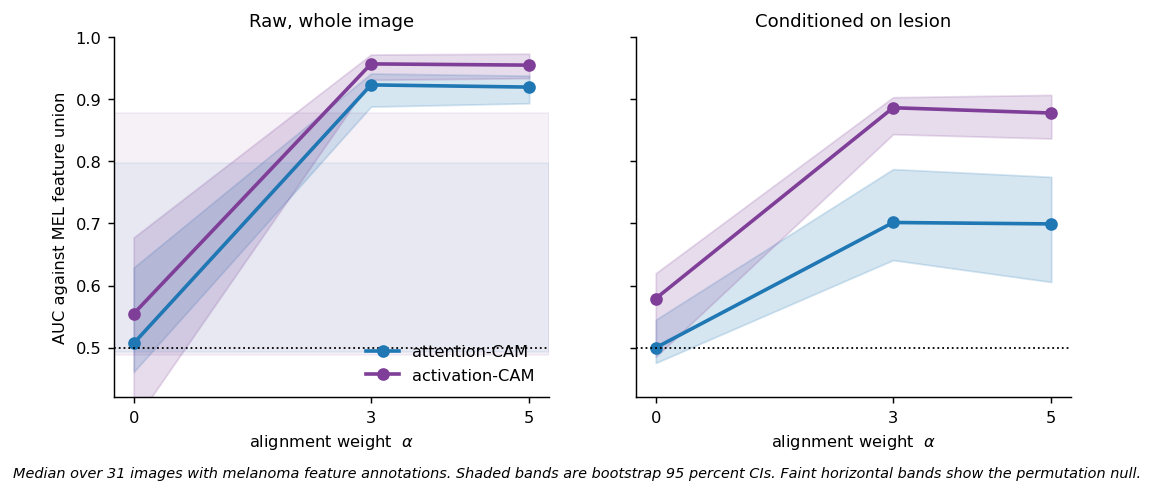

In [4]:
# =============================================================================
# FIGURE 1. Dose response.
#
# EXPECT: steep rise from alpha 0 to 3, flat from 3 to 5.
#         Raw curves above in-lesion curves. Null band around 0.78 to 0.88.
# READ:   the gap between a curve and its null band is the real effect.
#         Activation has the higher raw AUC and the smaller gap.
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharey=True)

for ax, (metric, df, title) in zip(axes, [
    ("cam_auc", mel_raw, "Raw, whole image"),
    ("c_auc",   mel_con, "Conditioned on lesion"),
]):
    for fam, ct, col, name in [
        ("attn", "attncam_a", C_ATTN, "attention-CAM"),
        ("act",  "gradcam_a", C_ACT,  "activation-CAM"),
    ]:
        sub = df[(df.family == fam) & (df.cam_type == ct)]
        xs, ys, los, his = [], [], [], []
        for ck in ALPHAS:
            v = sub[sub.ckpt == ck][metric]
            m, lo, hi = boot_median_ci(v)
            xs.append(AVAL[ck]); ys.append(m); los.append(lo); his.append(hi)
        ax.plot(xs, ys, "o-", color=col, label=name, lw=2, ms=6)
        ax.fill_between(xs, los, his, color=col, alpha=0.18)

    if metric == "cam_auc":
        for fam, col in [("attn", C_ATTN), ("act", C_ACT)]:
            n = nullcmp[(nullcmp.target == "union_MEL") &
                        nullcmp.source.str.startswith(fam)]
            if len(n):
                ax.axhspan(n.null_auc_mean.min(), n.null_auc_mean.max(),
                           color=col, alpha=0.07)

    ax.axhline(0.5, color="k", ls=":", lw=1)
    ax.set_xticks([0, 3, 5])
    ax.set_xlabel(r"alignment weight  $\alpha$")
    ax.set_title(title)
    ax.set_ylim(0.42, 1.0)

axes[0].set_ylabel("AUC against MEL feature union")
axes[0].legend(frameon=False, loc="lower right")
fig.text(0.5, -0.06,
         "Median over 31 images with melanoma feature annotations. "
         "Shaded bands are bootstrap 95 percent CIs. "
         "Faint horizontal bands show the permutation null.",
         ha="center", fontsize=8, style="italic")
fig.savefig(FIG / "fig1_E1_dose_response.png")
plt.show()

In [5]:
# =============================================================================
# E2. Does Finer-CAM outperform Grad-CAM on melanoma specific features.
# MEL class images only. n is small so effect size leads, p follows.
# =============================================================================
e2src = long_df[(long_df.target == "union_MEL") &
                (long_df.family == "act") &
                (long_df.ckpt == "ha5") &
                (long_df.gt_label == "MEL")].copy()

e2src["variant"] = np.where(
    e2src.cam_type == "finercam",
    "finercam_g" + e2src.gamma.astype(str).str.replace(".", "p", regex=False),
    e2src.cam_type)

print("available variants:", sorted(e2src.variant.unique()))
print(f"MEL images: {e2src.image_id.nunique()}\n")

rows = []
for a, b in [("finercam_g0p6", "gradcam_a"),
             ("finercam_g0p8", "gradcam_a"),
             ("finercam_g0p6", "finercam_g0p8"),
             ("map_diff",      "gradcam_a"),
             ("gradcam_a",     "gradcam_b")]:
    if a not in e2src.variant.values or b not in e2src.variant.values:
        continue
    r = paired_stats(e2src, "cam_auc", "variant", a, b)
    rows.append({"contrast": f"{a} vs {b}", **r})

e2 = pd.DataFrame(rows)
e2.to_csv(RES / "E2_statistics.csv", index=False)
for _, r in e2.iterrows():
    print(f"{r.contrast:<34} {fmt(r)}")

print("\ngradcam_a versus gradcam_b is the control.")
print("If the target and reference maps do not differ, Finer-CAM has")
print("no contrast to exploit and E2 cannot show an effect.")

available variants: ['finercam_g0p6', 'finercam_g0p8', 'gradcam_a', 'gradcam_b', 'map_diff']
MEL images: 15

finercam_g0p6 vs gradcam_a         n=15  diff=-0.002 [-0.005, -0.001]  p=0.0151  r=-0.70  (3/12)
finercam_g0p8 vs gradcam_a         n=15  diff=-0.014 [-0.016, -0.006]  p=0.0002  r=-0.97  (1/14)
finercam_g0p6 vs finercam_g0p8     n=15  diff=+0.010 [+0.004, +0.014]  p=0.0001  r=+0.98  (14/1)
map_diff vs gradcam_a              n=15  diff=-0.237 [-0.302, -0.181]  p=0.0001  r=-1.00  (0/15)
gradcam_a vs gradcam_b             n=15  diff=-0.000 [-0.005, +0.001]  p=0.5245  r=-0.20  (7/8)

gradcam_a versus gradcam_b is the control.
If the target and reference maps do not differ, Finer-CAM has
no contrast to exploit and E2 cannot show an effect.


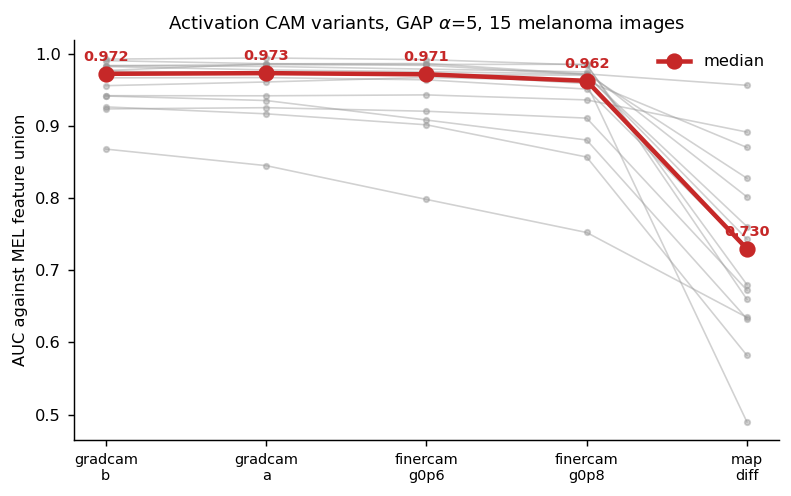

In [6]:
# =============================================================================
# FIGURE 2. Paired slope plot.
#
# EXPECT: near horizontal lines. Every image scores the same under both
#         methods. map_diff sits clearly lower.
# READ:   flat lines are the result. There is nothing for Finer-CAM to add.
# =============================================================================
order = ["gradcam_b", "gradcam_a", "finercam_g0p6", "finercam_g0p8", "map_diff"]
order = [v for v in order if v in e2src.variant.values]
piv = e2src.pivot_table(index="image_id", columns="variant",
                        values="cam_auc")[order].dropna()

fig, ax = plt.subplots(figsize=(7.0, 4.0))
x = np.arange(len(order))
for _, row in piv.iterrows():
    ax.plot(x, row.to_numpy(), "-o", color="#999999", alpha=0.45, ms=3, lw=0.9)

med = piv.median()
ax.plot(x, med.to_numpy(), "-o", color=C_MEL, lw=2.5, ms=8, label="median")
for xi, v in zip(x, med.to_numpy()):
    ax.text(xi, v + 0.018, f"{v:.3f}", ha="center", fontsize=8,
            color=C_MEL, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([o.replace("_", "\n") for o in order], fontsize=8)
ax.set_ylabel("AUC against MEL feature union")
ax.set_title(f"Activation CAM variants, GAP $\\alpha$=5, {len(piv)} melanoma images")
ax.legend(frameon=False)
fig.savefig(FIG / "fig2_E2_paired_slope.png")
plt.show()

In [7]:
# =============================================================================
# E4. Does alignment training collapse class discriminativeness.
#
# The 12c table gave medians only. Recompute per image so the effect
# can carry a confidence interval and a paired test.
# =============================================================================
cams, src_meta = {}, {}
for _, r in man.iterrows():
    if r.family == "activation":
        if r.cam_type != "finercam" and float(r.gamma) != 0.6:
            continue
        src = (f"act_{r.ckpt}_{r.cam_type}_gam{str(r.gamma).replace('.','p')}"
               if r.cam_type == "finercam" else f"act_{r.ckpt}_{r.cam_type}")
    else:
        src = f"attn_{r.ckpt}_{r.cam_type}"
    arr = np.load(REPO / r.path)
    cams[(r.image_id, src)] = (cam_to_grid(arr)
                               if arr.shape != (CAM_GRID, CAM_GRID) else arr)
    src_meta[src] = {"family": "attn" if r.family == "attention" else "act",
                     "ckpt": r.ckpt, "cam_type": r.cam_type}


def topk_fixed(c, k=TOP_K):
    f = np.asarray(c, np.float32).ravel()
    o = np.zeros(f.size, bool)
    o[np.argpartition(-f, k - 1)[:k]] = True
    return o.reshape(c.shape)


rows = []
for fam, a, b in [("act", "gradcam_a", "gradcam_b"),
                  ("attn", "attncam_a", "attncam_b")]:
    for ck in ALPHAS:
        sa, sb = f"{fam}_{ck}_{a}", f"{fam}_{ck}_{b}"
        for img in eval_df.image_id:
            ca, cb = cams.get((img, sa)), cams.get((img, sb))
            if ca is None or cb is None:
                continue
            na, nb = norm01(ca), norm01(cb)
            ma, mb = topk_fixed(na), topk_fixed(nb)
            rows.append({
                "image_id": img, "family": fam, "ckpt": ck,
                "alpha": AVAL[ck],
                "pearson": float(np.corrcoef(na.ravel(), nb.ravel())[0, 1]),
                "topk_iou": float((ma & mb).sum() / ((ma | mb).sum() + 1e-8)),
                "mad": float(np.abs(na - nb).mean()),
            })

disc = pd.DataFrame(rows)
disc = disc.merge(pred[["image_id", "gt_label", "case_type"]], on="image_id")
disc.to_csv(RES / "E4_discriminativeness_per_image.csv", index=False)

print("class discriminativeness, median with bootstrap 95 percent CI\n")
for fam, name in [("attn", "attention-CAM"), ("act", "activation-CAM")]:
    print(name)
    for ck in ALPHAS:
        s = disc[(disc.family == fam) & (disc.ckpt == ck)]
        pm, plo, phi = boot_median_ci(s.pearson)
        im, ilo, ihi = boot_median_ci(s.topk_iou)
        print(f"  {ck}  pearson {pm:+.3f} [{plo:+.3f}, {phi:+.3f}]   "
              f"IoU {im:.3f} [{ilo:.3f}, {ihi:.3f}]   n={len(s)}")
    print()

print("paired tests, pearson similarity between class maps")
for fam, name in [("attn", "attention"), ("act", "activation")]:
    s = disc[disc.family == fam]
    for a, b in [("ha3", "ha0"), ("ha5", "ha0")]:
        r = paired_stats(s, "pearson", "ckpt", a, b)
        print(f"  {name:<11} {a} vs {b}  {fmt(r)}")

class discriminativeness, median with bootstrap 95 percent CI

attention-CAM
  ha0  pearson -0.275 [-0.298, -0.250]   IoU 0.000 [0.000, 0.000]   n=34
  ha3  pearson +0.960 [+0.950, +0.967]   IoU 0.356 [0.290, 0.481]   n=34
  ha5  pearson +0.968 [+0.952, +0.975]   IoU 0.333 [0.290, 0.379]   n=34

activation-CAM
  ha0  pearson -0.435 [-0.451, -0.385]   IoU 0.000 [0.000, 0.000]   n=34
  ha3  pearson +0.993 [+0.991, +0.995]   IoU 0.818 [0.818, 0.905]   n=34
  ha5  pearson +0.996 [+0.994, +0.997]   IoU 0.818 [0.818, 0.905]   n=34

paired tests, pearson similarity between class maps
  attention   ha3 vs ha0  n=34  diff=+1.238 [+1.187, +1.266]  p=0.0000  r=+1.00  (34/0)
  attention   ha5 vs ha0  n=34  diff=+1.241 [+1.195, +1.275]  p=0.0000  r=+1.00  (34/0)
  activation  ha3 vs ha0  n=34  diff=+1.426 [+1.379, +1.445]  p=0.0000  r=+1.00  (34/0)
  activation  ha5 vs ha0  n=34  diff=+1.427 [+1.381, +1.447]  p=0.0000  r=+1.00  (34/0)


best demonstration images:
              ha0    ha3    ha5   gain gt_label case_type
image_id                                                 
ISIC_0024886  0.0  0.739  0.739  0.739      MEL    FN_MEL
ISIC_0030552  0.0  0.600  0.600  0.600      MEL    FN_MEL
ISIC_0032462  0.0  0.429  0.538  0.538      MEL    TP_MEL
ISIC_0031565  0.0  0.538  0.538  0.538      MEL    TP_MEL
ISIC_0029013  0.0  0.481  0.481  0.481      MEL    FN_MEL

using ISIC_0029089


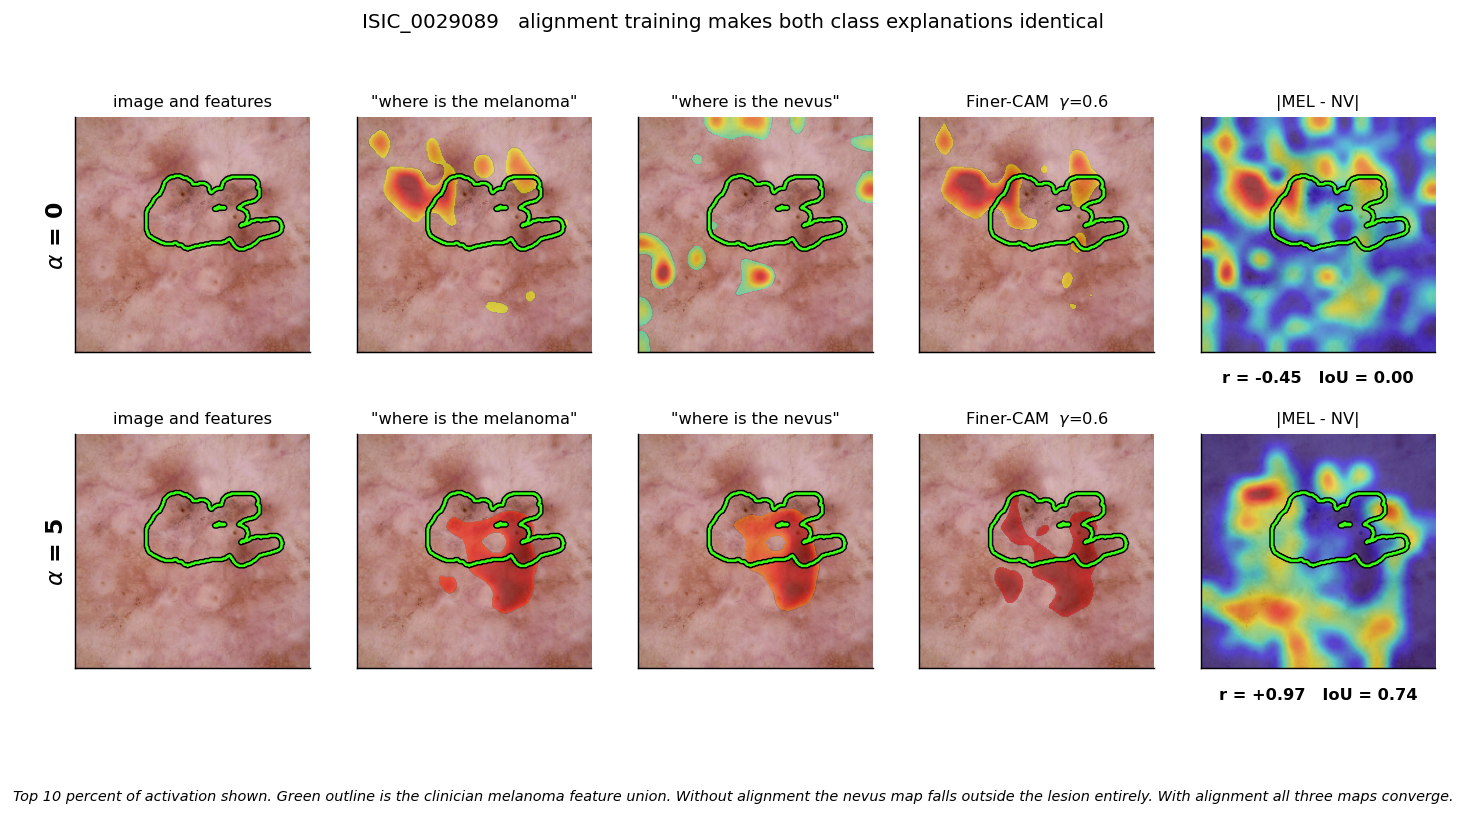

In [8]:
# =============================================================================
# FIGURE 3. The headline.
#
# One image. Top row alpha=0. Bottom row alpha=5.
# Columns: image with feature outline, MEL map, NV map, difference.
#
# EXPECT: at alpha=0 the MEL and NV maps light different regions.
#         at alpha=5 they are visually identical and the difference is empty.
# READ:   this is the entire finding in one picture.
# =============================================================================
sel = (disc[(disc.family == "attn")]
       .pivot_table(index="image_id", columns="ckpt", values="topk_iou"))
sel["gain"] = sel["ha5"] - sel["ha0"]
sel = sel.join(pred.set_index("image_id")[["gt_label", "case_type"]])
cand = sel[sel.gt_label == "MEL"].sort_values("gain", ascending=False)
print("best demonstration images:")
print(cand.head(5).round(3).to_string())

HERO = cand.index[6]          # override manually if a nicer image exists
# FAM  = "attn"                 # "act" collapses harder, "attn" is your model
# HERO = "ISIC_0029013"
FAM  = "act"
print(f"\nusing {HERO}")


def cropped_rgb(image_id):
    rel = eval_df.set_index("image_id").loc[image_id, "image_rel_path"]
    img = np.array(Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB"))
    s = RESIZE_SHORT / min(img.shape[:2])
    nh, nw = int(round(img.shape[0] * s)), int(round(img.shape[1] * s))
    im = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LINEAR)
    t, l = (nh - CROP_SIZE) // 2, (nw - CROP_SIZE) // 2
    return im[t:t + CROP_SIZE, l:l + CROP_SIZE]


def mel_union_mask(image_id):
    sub = qcp[(qcp.Image_ID == image_id) & (qcp.label_group == "MEL")]
    if not len(sub):
        return None
    acc = None
    for _, r in sub.iterrows():
        m = np.array(Image.open(r.mask_path).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    return resize_centercrop_mask(acc)[0]


def overlay(ax, rgb, cam=None, outline=None, title=None, topk=True):
    ax.imshow(rgb)
    if cam is not None:
        c = norm01(cam)
        c = cv2.resize(c, rgb.shape[:2][::-1], interpolation=cv2.INTER_CUBIC)
        if topk:
            thr = np.percentile(c, 100 - 100 * TOP_K / CAM_GRID ** 2)
            c = np.where(c >= thr, c, np.nan)
        ax.imshow(c, cmap="jet", alpha=0.55, vmin=0, vmax=1)
    if outline is not None:
        ax.contour(outline.astype(float), [0.5], colors="white", linewidths=1.4)
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=9)

# =============================================================================
# FIGURE 3. Headline. Activation family so Finer-CAM can be included.
#
# 2 rows x 5 columns.
#   image | GradCAM MEL | GradCAM NV | Finer-CAM | absolute difference
#
# EXPECT alpha=0 : the two class maps light different regions, difference bright
# EXPECT alpha=5 : maps identical, Finer-CAM identical to GradCAM, difference empty
# =============================================================================

rgb = cropped_rgb(HERO)
un  = mel_union_mask(HERO)


def overlay(ax, rgb, cam=None, outline=None, title=None, topk=True):
    ax.imshow(rgb)
    if cam is not None:
        c = norm01(cam)
        c = cv2.resize(c, rgb.shape[:2][::-1], interpolation=cv2.INTER_CUBIC)
        if topk:
            thr = np.percentile(c, 100 - 100 * TOP_K / CAM_GRID ** 2)
            c = np.where(c >= thr, c, np.nan)
        ax.imshow(c, cmap="jet", alpha=0.55, vmin=0, vmax=1)
    if outline is not None:
        o = outline.astype(float)
        ax.contour(o, [0.5], colors="black", linewidths=3.0)
        ax.contour(o, [0.5], colors="#39FF14", linewidths=1.4)
    ax.set_xticks([]); ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(2, 5, figsize=(13.5, 5.8))

for row, ck in enumerate(["ha0", "ha5"]):
    ca = cams[(HERO, f"{FAM}_{ck}_gradcam_a")]
    cb = cams[(HERO, f"{FAM}_{ck}_gradcam_b")]
    cf = cams[(HERO, f"{FAM}_{ck}_finercam_gam0p6")]
    d  = np.abs(norm01(ca) - norm01(cb))
    r  = disc[(disc.image_id == HERO) & (disc.family == FAM) &
              (disc.ckpt == ck)].iloc[0]

    overlay(axes[row, 0], rgb, None, un, "image and features")
    overlay(axes[row, 1], rgb, ca, un, '"where is the melanoma"')
    overlay(axes[row, 2], rgb, cb, un, '"where is the nevus"')
    overlay(axes[row, 3], rgb, cf, un, "Finer-CAM  $\\gamma$=0.6")
    overlay(axes[row, 4], rgb, d,  un, "|MEL - NV|", topk=False)

    axes[row, 0].set_ylabel(f"$\\alpha$ = {AVAL[ck]}", fontsize=13,
                            fontweight="bold")
    axes[row, 4].text(0.5, -0.13,
                      f"r = {r.pearson:+.2f}   IoU = {r.topk_iou:.2f}",
                      transform=axes[row, 4].transAxes, ha="center",
                      fontsize=9, fontweight="bold")

fig.suptitle(
    f"{HERO}   alignment training makes both class explanations identical",
    fontsize=11, y=1.00)
fig.text(0.5, -0.045,
         "Top 10 percent of activation shown. Green outline is the clinician "
         "melanoma feature union. Without alignment the nevus map falls outside "
         "the lesion entirely. With alignment all three maps converge.",
         ha="center", fontsize=8, style="italic")
fig.savefig(FIG / "fig3_E4_discriminativeness_collapse.png")
plt.show()

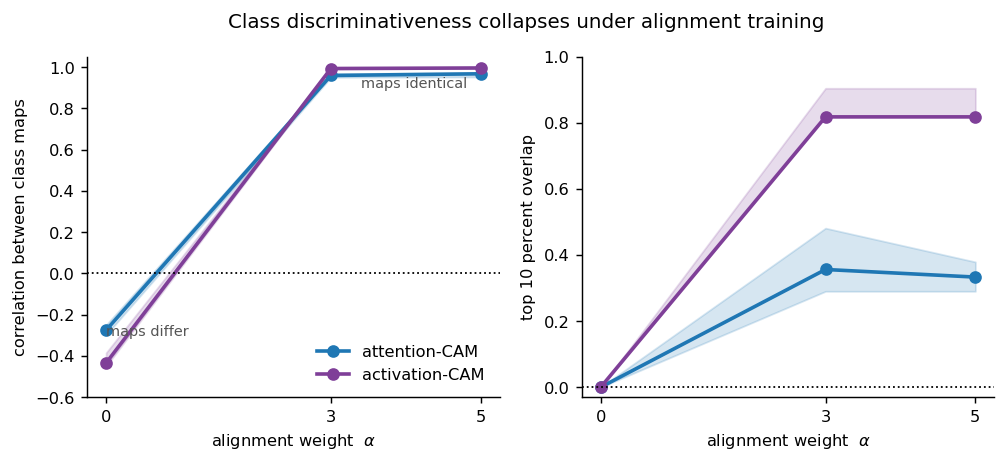

In [9]:
# =============================================================================
# FIGURE 4. Collapse as a function of alpha.
#
# EXPECT: pearson jumps from negative to near 1.0 between alpha 0 and 3.
#         activation collapses harder than attention.
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

for ax, metric, ylab, ylim in [
    (axes[0], "pearson",  "correlation between class maps", (-0.6, 1.05)),
    (axes[1], "topk_iou", "top 10 percent overlap",         (-0.03, 1.0)),
]:
    for fam, col, name in [("attn", C_ATTN, "attention-CAM"),
                           ("act", C_ACT, "activation-CAM")]:
        xs, ys, lo, hi = [], [], [], []
        for ck in ALPHAS:
            v = disc[(disc.family == fam) & (disc.ckpt == ck)][metric]
            m, l, h = boot_median_ci(v)
            xs.append(AVAL[ck]); ys.append(m); lo.append(l); hi.append(h)
        ax.plot(xs, ys, "o-", color=col, lw=2, ms=6, label=name)
        ax.fill_between(xs, lo, hi, color=col, alpha=0.18)
    ax.axhline(0, color="k", ls=":", lw=1)
    ax.set_xticks([0, 3, 5])
    ax.set_xlabel(r"alignment weight  $\alpha$")
    ax.set_ylabel(ylab)
    ax.set_ylim(*ylim)

axes[0].legend(frameon=False, loc="lower right")
axes[0].annotate("maps differ", xy=(0, -0.3), fontsize=8, color="#555555")
axes[0].annotate("maps identical", xy=(3.4, 0.90), fontsize=8, color="#555555")
fig.suptitle("Class discriminativeness collapses under alignment training",
             fontsize=11)
fig.savefig(FIG / "fig4_E4_collapse_curve.png")
plt.show()

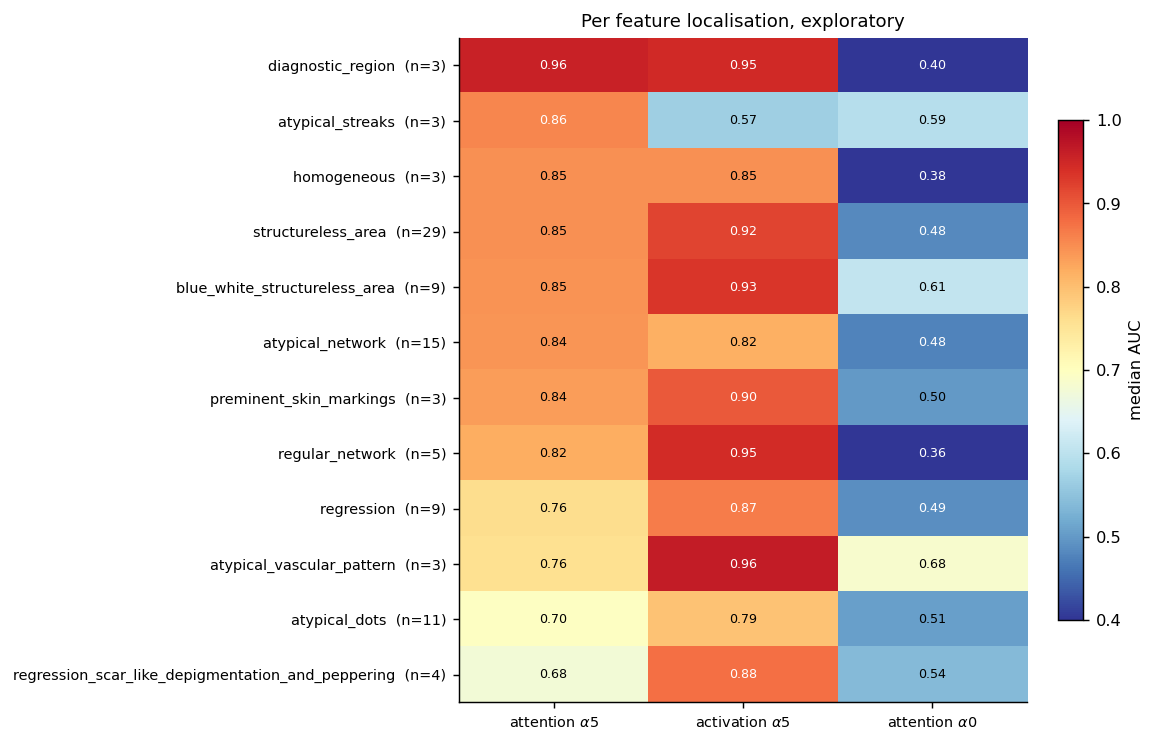

                                                   attention $\alpha$5  activation $\alpha$5  attention $\alpha$0
label                                                                                                            
diagnostic_region                                                0.957                 0.948                0.395
atypical_streaks                                                 0.857                 0.568                0.594
homogeneous                                                      0.847                 0.847                0.381
structureless_area                                               0.847                 0.918                0.483
blue_white_structureless_area                                    0.845                 0.932                0.607
atypical_network                                                 0.842                 0.815                0.475
preminent_skin_markings                                          0.835                 0

In [10]:
# =============================================================================
# E3. Which individual features does the CAM localise.
# EXPLORATORY. Labels overlap spatially so these are not independent.
#
# EXPECT: large diffuse labels score high. small focal labels score low.
# WATCH:  n below 4 is anecdote, not evidence. Shown for completeness only.
# =============================================================================
lab = long_df[long_df.target_kind == "label"].copy()
lab["label"] = lab.target.str.replace("label_", "", regex=False)

counts = lab.groupby("label").image_id.nunique()
keep = counts[counts >= 3].index.tolist()

src_show = [("attn", "attncam_a", "ha5", "attention $\\alpha$5"),
            ("act",  "gradcam_a", "ha5", "activation $\\alpha$5"),
            ("attn", "attncam_a", "ha0", "attention $\\alpha$0")]

mat = {}
for fam, ct, ck, name in src_show:
    s = lab[(lab.family == fam) & (lab.cam_type == ct) & (lab.ckpt == ck)]
    mat[name] = s[s.label.isin(keep)].groupby("label").cam_auc.median()
hm = pd.DataFrame(mat).reindex(
    sorted(keep, key=lambda l: mat[src_show[0][3]].get(l, 0), reverse=True))

fig, ax = plt.subplots(figsize=(6.2, 0.42 * len(hm) + 1.6))
im = ax.imshow(hm.to_numpy(), cmap="RdYlBu_r", vmin=0.4, vmax=1.0, aspect="auto")
ax.set_xticks(range(hm.shape[1]))
ax.set_xticklabels(hm.columns, fontsize=8)
ax.set_yticks(range(len(hm)))
ax.set_yticklabels([f"{l}  (n={counts[l]})" for l in hm.index], fontsize=8)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.iat[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if v > 0.85 or v < 0.5 else "black")
plt.colorbar(im, ax=ax, label="median AUC", fraction=0.04)
ax.set_title("Per feature localisation, exploratory", fontsize=10)
fig.savefig(FIG / "fig5_E3_per_label.png")
plt.show()

print(hm.round(3).to_string())

In [11]:
# =============================================================================
# Does alignment quality depend on whether the model was correct.
# EXPECT: no strong pattern. HA changed where the model looks, not what it
#         decides, and only one image flips prediction across alpha.
# =============================================================================
ct = mel_raw[(mel_raw.family == "attn") & (mel_raw.cam_type == "attncam_a") &
             (mel_raw.ckpt == "ha5")]
print("attention alpha5, MEL union AUC by case type:")
print(ct.groupby("case_type").cam_auc.agg(["count", "median"]).round(3).to_string())

r = paired_stats(
    ct.assign(grp=np.where(ct.correct, "correct", "wrong")).assign(
        image_id=ct.image_id),
    "cam_auc", "grp", "correct", "wrong") if ct.correct.nunique() > 1 else None

print("\ncorrect versus wrong, unpaired medians:")
print(ct.groupby("correct").cam_auc.agg(["count", "median"]).round(3).to_string())

attention alpha5, MEL union AUC by case type:
           count  median
case_type               
FN_MEL         3   0.938
FP_MEL        10   0.934
TN_NV          6   0.835
TP_MEL        12   0.922

correct versus wrong, unpaired medians:
         count  median
correct               
False       13   0.938
True        18   0.884


In [12]:
# =============================================================================
# One table for the thesis.
# =============================================================================
summary = []
for fam, ct_, name in [("attn", "attncam_a", "attention-CAM"),
                       ("act", "gradcam_a", "activation-CAM")]:
    for ck in ALPHAS:
        raw = mel_raw[(mel_raw.family == fam) & (mel_raw.cam_type == ct_) &
                      (mel_raw.ckpt == ck)].cam_auc
        con = mel_con[(mel_con.family == fam) & (mel_con.cam_type == ct_) &
                      (mel_con.ckpt == ck)].c_auc
        d = disc[(disc.family == fam) & (disc.ckpt == ck)]
        nl = nullcmp[(nullcmp.target == "union_MEL") &
                     (nullcmp.source == f"{fam}_{ck}_{ct_}")]
        rm, rlo, rhi = boot_median_ci(raw)
        cm, clo, chi = boot_median_ci(con)
        summary.append({
            "formulation": name, "alpha": AVAL[ck], "n": len(raw),
            "auc_raw": rm, "raw_ci": f"[{rlo:.3f}, {rhi:.3f}]",
            "auc_null": float(nl.null_auc_mean.iloc[0]) if len(nl) else np.nan,
            "auc_in_lesion": cm, "lesion_ci": f"[{clo:.3f}, {chi:.3f}]",
            "class_pearson": float(d.pearson.median()),
            "class_iou": float(d.topk_iou.median()),
        })

s = pd.DataFrame(summary)
s["auc_above_null"] = s.auc_raw - s.auc_null
s.to_csv(RES / "summary_table.csv", index=False)
print(s.round(3).to_string(index=False))

   formulation  alpha  n  auc_raw         raw_ci  auc_null  auc_in_lesion      lesion_ci  class_pearson  class_iou  auc_above_null
 attention-CAM      0 31    0.507 [0.461, 0.629]     0.494          0.500 [0.476, 0.545]         -0.275      0.000           0.013
 attention-CAM      3 31    0.923 [0.888, 0.941]     0.784          0.702 [0.641, 0.787]          0.960      0.356           0.139
 attention-CAM      5 31    0.920 [0.893, 0.938]     0.795          0.699 [0.606, 0.775]          0.968      0.333           0.125
activation-CAM      0 31    0.555 [0.380, 0.677]     0.520          0.579 [0.486, 0.620]         -0.435      0.000           0.035
activation-CAM      3 31    0.957 [0.931, 0.972]     0.877          0.886 [0.844, 0.903]          0.993      0.818           0.080
activation-CAM      5 31    0.955 [0.934, 0.973]     0.872          0.878 [0.837, 0.907]          0.996      0.818           0.083


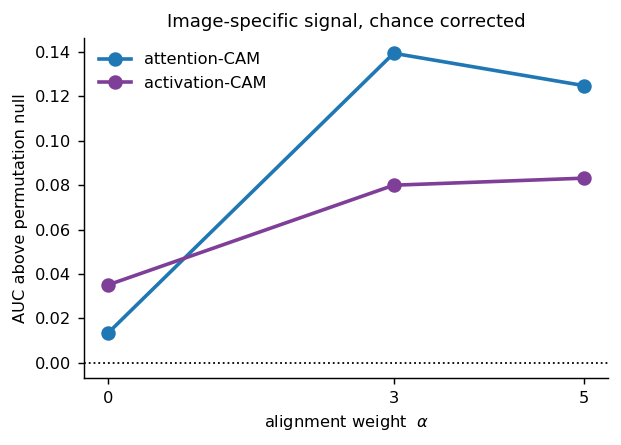

          name  alpha   obs  null  margin
 attention-CAM      0 0.507 0.494   0.013
 attention-CAM      3 0.923 0.784   0.139
 attention-CAM      5 0.920 0.795   0.125
activation-CAM      0 0.555 0.520   0.035
activation-CAM      3 0.957 0.877   0.080
activation-CAM      5 0.955 0.872   0.083


In [13]:
# =============================================================================
# FIGURE 6. Margin over the permutation null.
# EXPECT: attention above activation at alpha 3 and 5, reversing figure 1.
# =============================================================================
rows = []
for fam, ct_, name in [("attn", "attncam_a", "attention-CAM"),
                       ("act",  "gradcam_a", "activation-CAM")]:
    for ck in ALPHAS:
        obs = mel_raw[(mel_raw.family == fam) & (mel_raw.cam_type == ct_) &
                      (mel_raw.ckpt == ck)].cam_auc.median()
        nl = nullcmp[(nullcmp.target == "union_MEL") &
                     (nullcmp.source == f"{fam}_{ck}_{ct_}")]
        rows.append({"name": name, "alpha": AVAL[ck], "obs": obs,
                     "null": float(nl.null_auc_mean.iloc[0]) if len(nl) else np.nan})
m = pd.DataFrame(rows)
m["margin"] = m.obs - m["null"]

fig, ax = plt.subplots(figsize=(5.2, 3.4))
for name, col in [("attention-CAM", C_ATTN), ("activation-CAM", C_ACT)]:
    s = m[m.name == name]
    ax.plot(s.alpha, s.margin, "o-", color=col, lw=2, ms=7, label=name)
ax.axhline(0, color="k", ls=":", lw=1)
ax.set_xticks([0, 3, 5])
ax.set_xlabel(r"alignment weight  $\alpha$")
ax.set_ylabel("AUC above permutation null")
ax.set_title("Image-specific signal, chance corrected")
ax.legend(frameon=False)
fig.savefig(FIG / "fig6_null_margin.png")
plt.show()
print(m.round(3).to_string(index=False))